In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import illumination_functions as ilf

In [2]:
# Step 1: Load your H5 file
filename = r"E:\mjosa\29\uhi_rad\rad_uhi_20241029_121639_1.h5"
with h5py.File(filename, "r") as h5file:
    # Adjust the key below to match your dataset name
    # Example: if your hyperspectral cube is stored under the key 'data'
    data = h5file["processed/radiance/dataCube"][
        :
    ]  # Assuming shape: (n_tracks, n_slit_pixels, n_wavelengths)

    band_2_wavelength = h5file[
        "processed/radiance/calibration/spectral/band2Wavelength"
    ][:]

ilf.describe_data(data)

=== Data Overview ===
Shape of data: (1593, 968, 210) (tracks, slit_pixels, wavelengths)
 - Number of tracks (time steps): 1593
 - Number of slit pixels: 968
 - Number of wavelengths: 210
Global Intensity Range: 0.000 to 1.295


In [3]:
# print("Shape of band_2_wavelength:", band_2_wavelength.shape)
# print("Contents of band_2_wavelength:", band_2_wavelength)

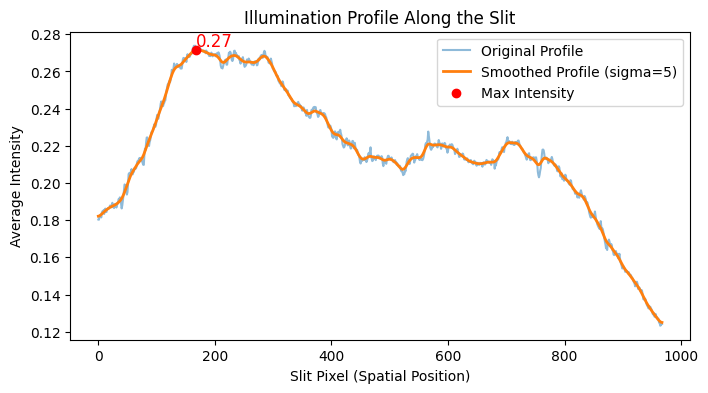

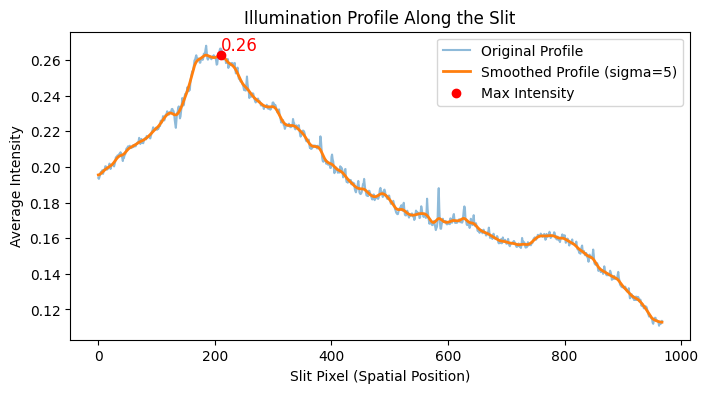

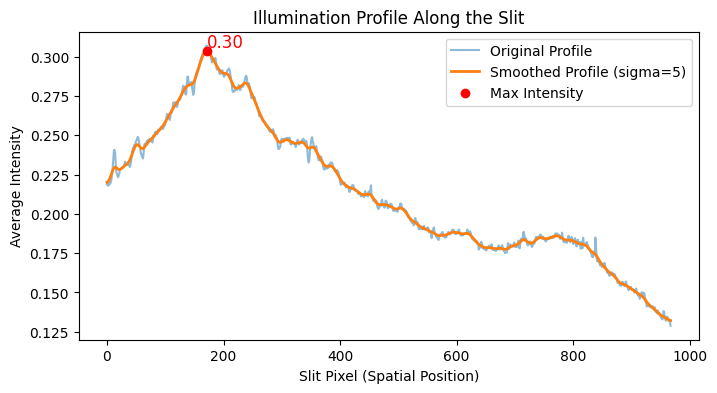

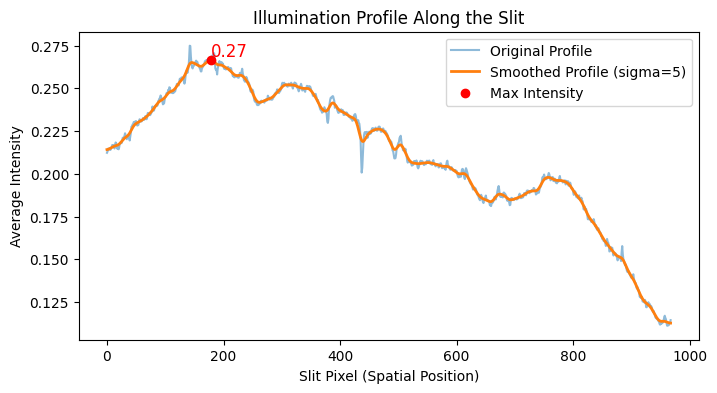

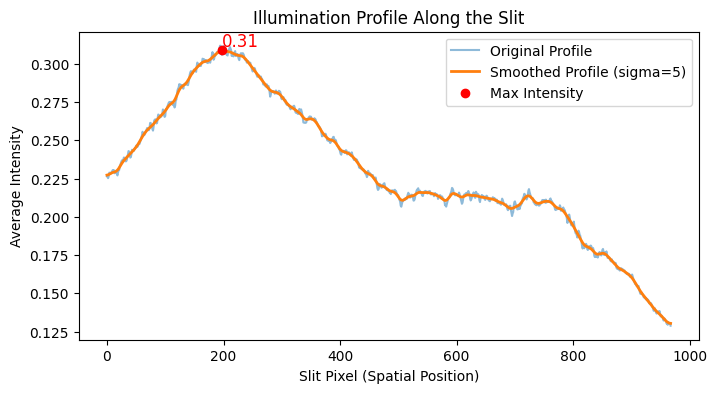

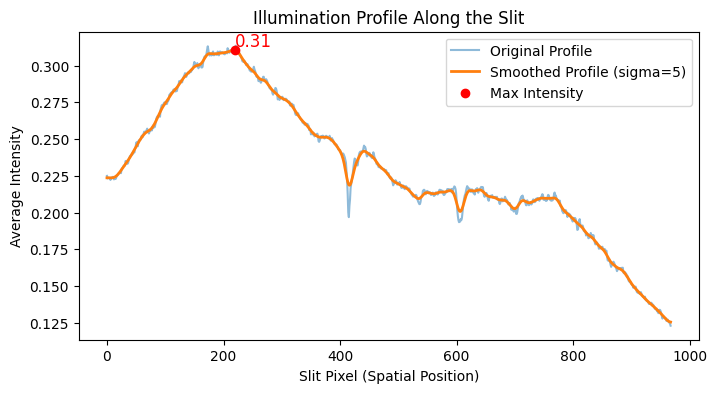

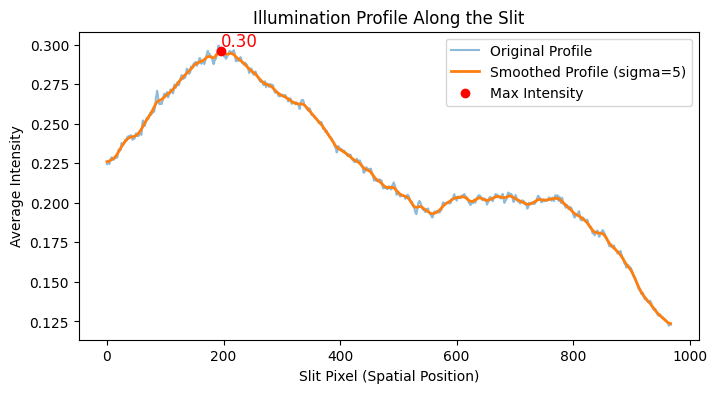

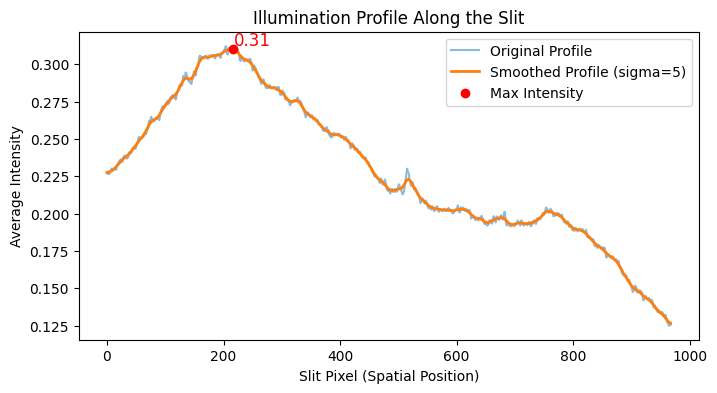

In [4]:
ilf.plot_mean_intensity(data, track_index=100)
ilf.plot_mean_intensity(data, track_index=200)
ilf.plot_mean_intensity(data, track_index=300)
ilf.plot_mean_intensity(data, track_index=400)
ilf.plot_mean_intensity(data, track_index=500)
ilf.plot_mean_intensity(data, track_index=600)
ilf.plot_mean_intensity(data, track_index=700)
ilf.plot_mean_intensity(data, track_index=800)

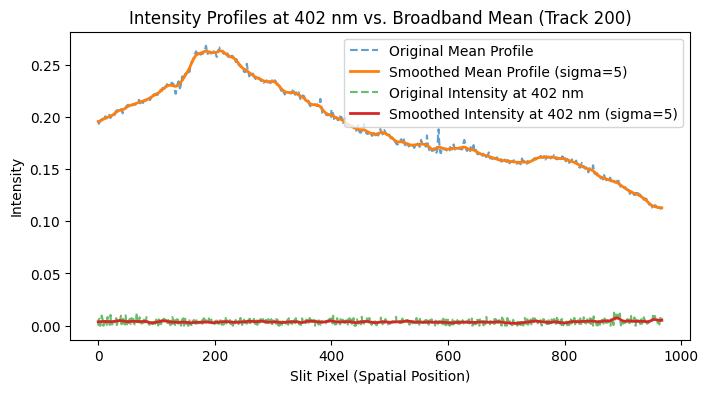

In [5]:
ilf.plot_wavelength_vs_mean(
    data, band_2_wavelength, desired_wavelength=402, sigma=5, track_index=200
)

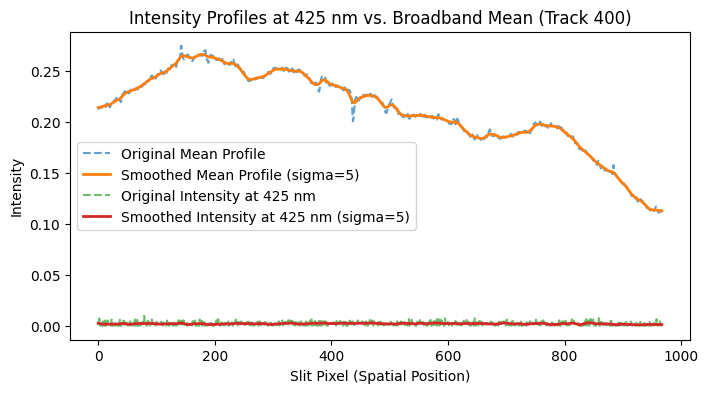

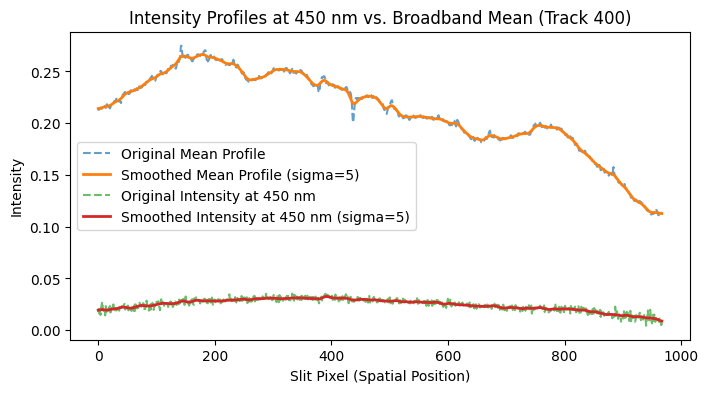

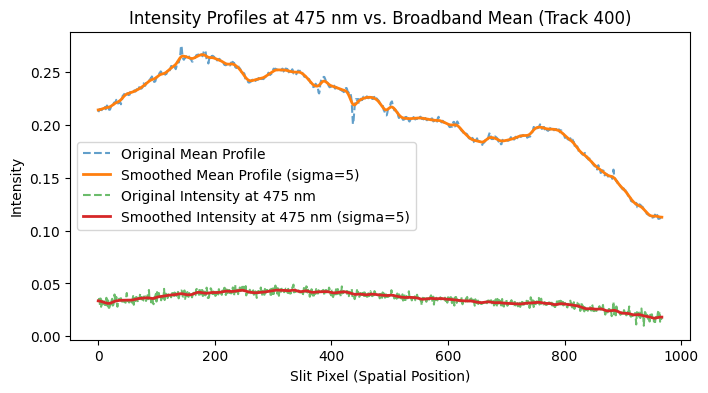

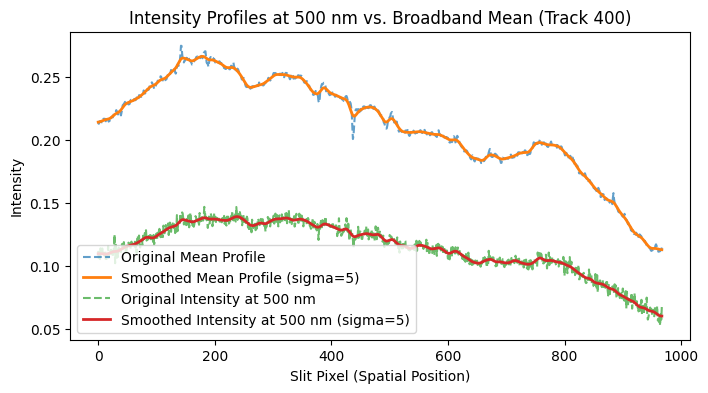

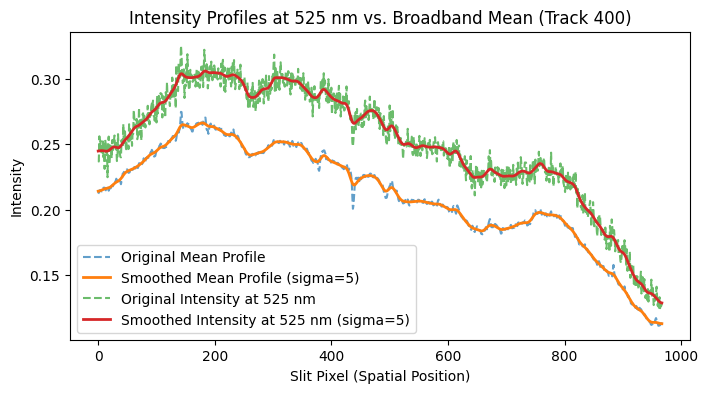

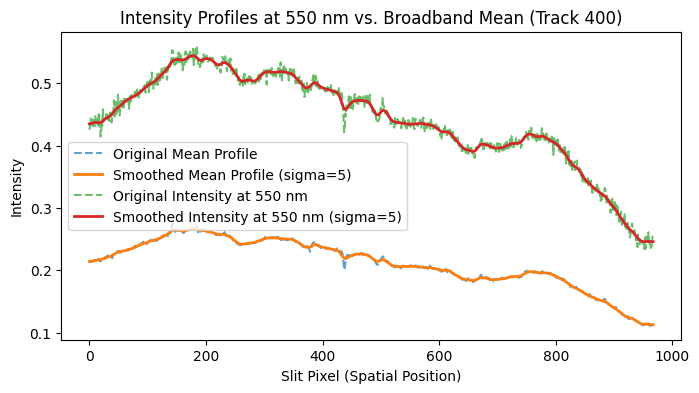

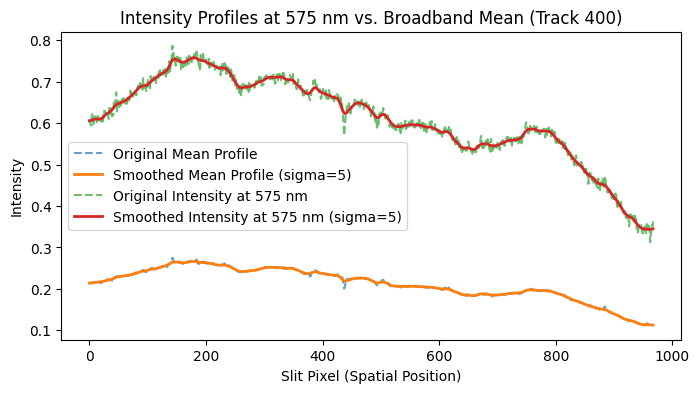

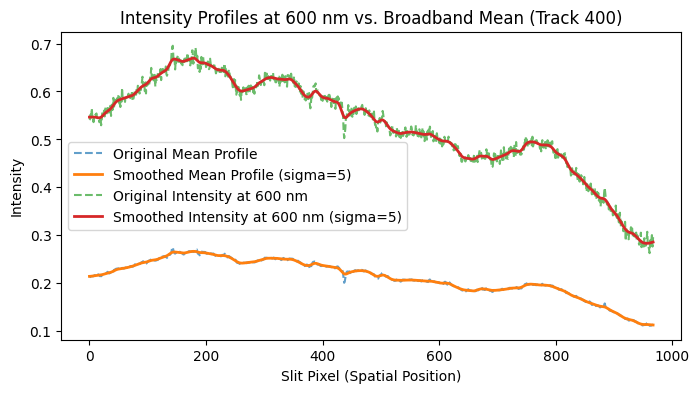

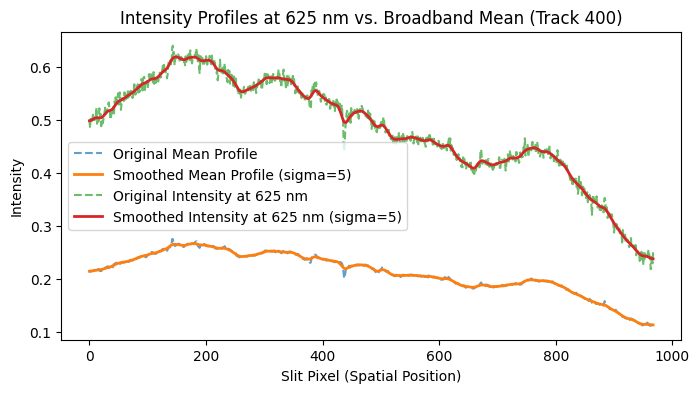

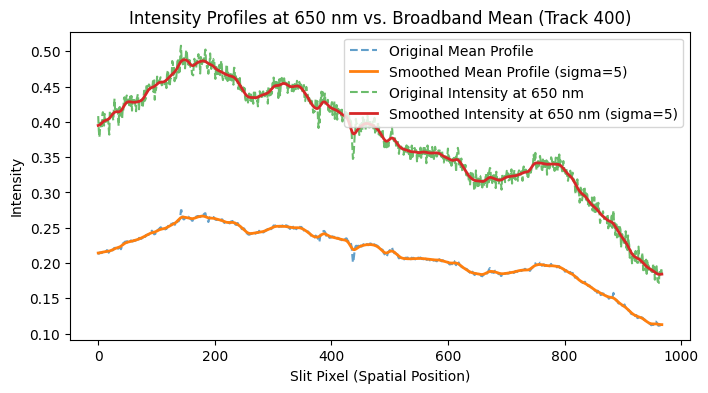

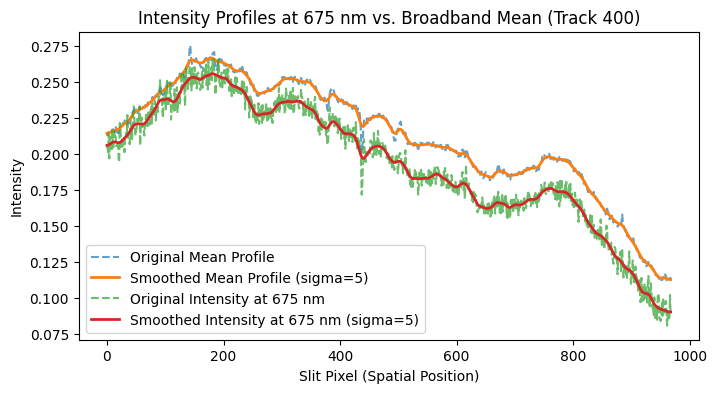

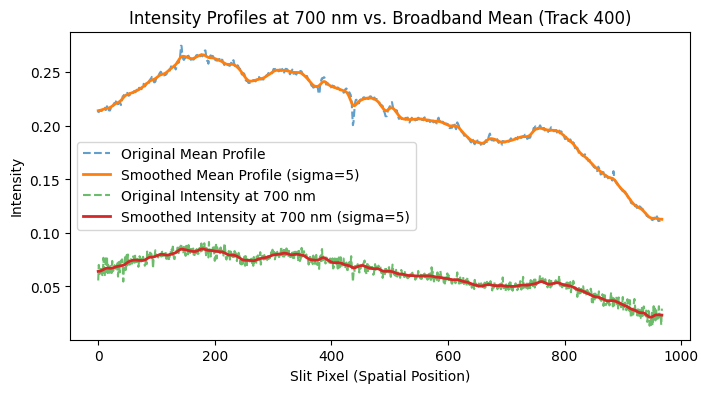

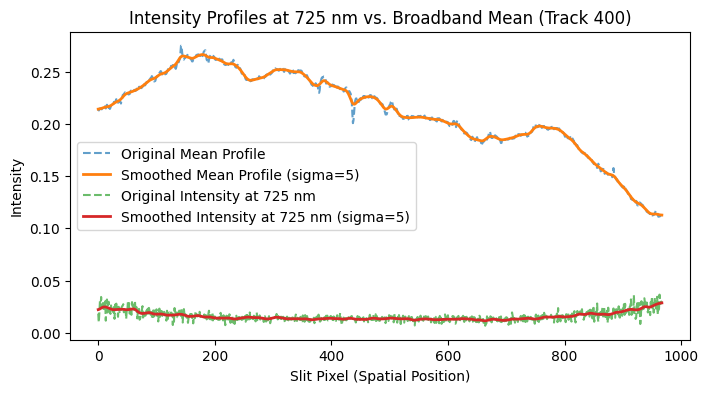

In [6]:
for i in range(13):
    ilf.plot_wavelength_vs_mean(
        data,
        band_2_wavelength,
        desired_wavelength=425 + i * 25,
        sigma=5,
        track_index=400,
    )

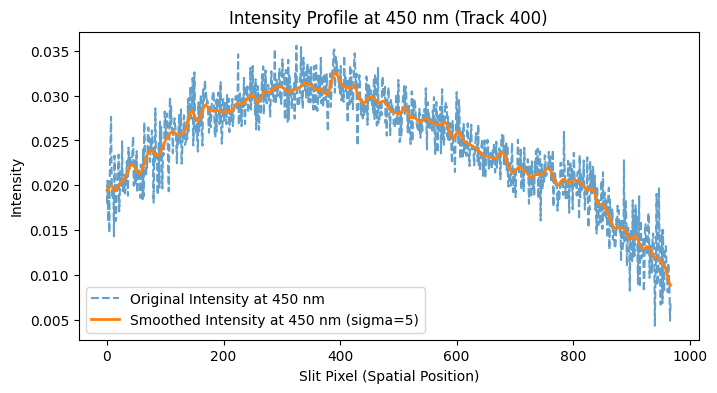

In [7]:
ilf.plot_wavelength_intensity(
    data,
    wavelengths=band_2_wavelength,
    desired_wavelength=450,
    track_index=400,
    sigma=5,
)

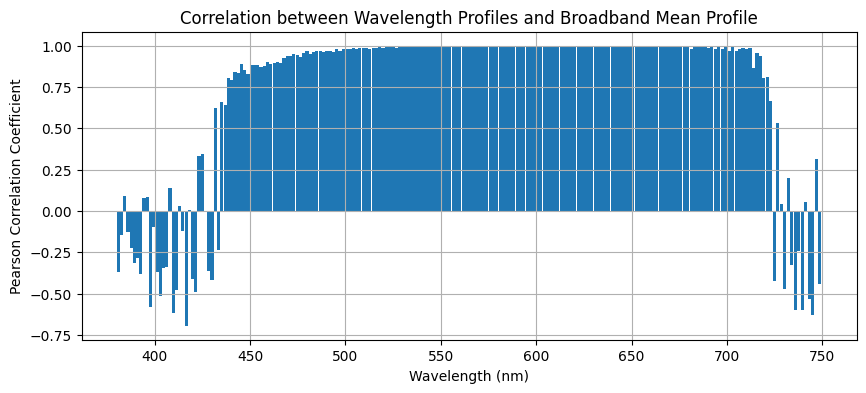

In [8]:
# for i in range(14):
#     ilf.compare_wavelengths_to_mean(
#         data, band_2_wavelength, sigma=5, track_index=i * 100
#     )

ilf.compare_wavelengths_to_mean(data, band_2_wavelength, sigma=5, track_index=400)
# ilf.compare_wavelengths_to_mean_rmse(data, band_2_wavelength, sigma=5, track_index=200)

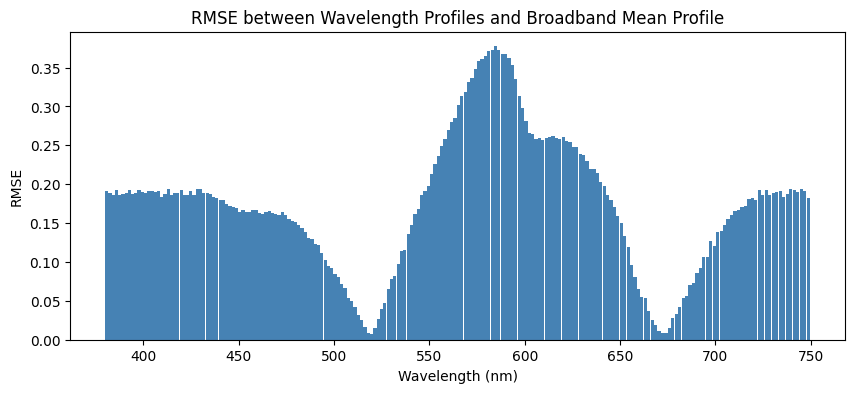

In [9]:
ilf.compare_wavelengths_to_mean_rmse(
    data, track_index=200, wavelengths=band_2_wavelength
)

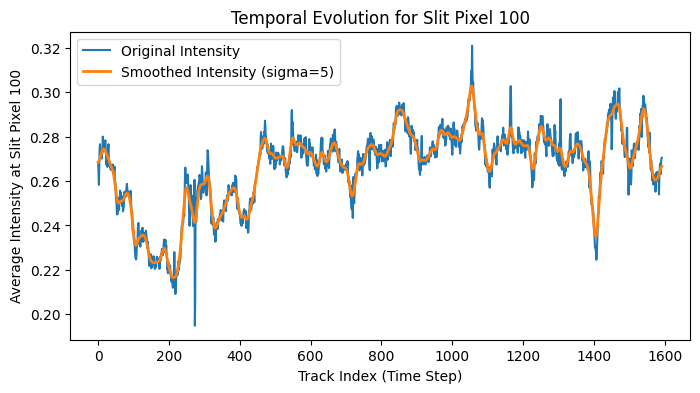

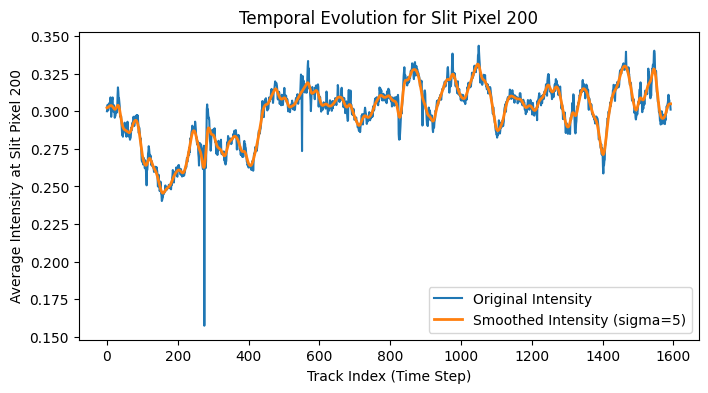

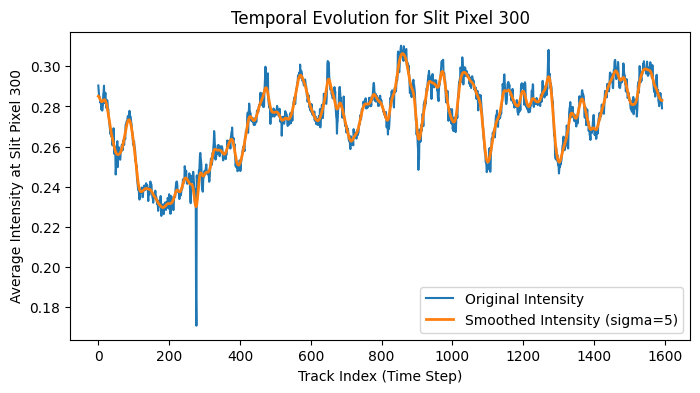

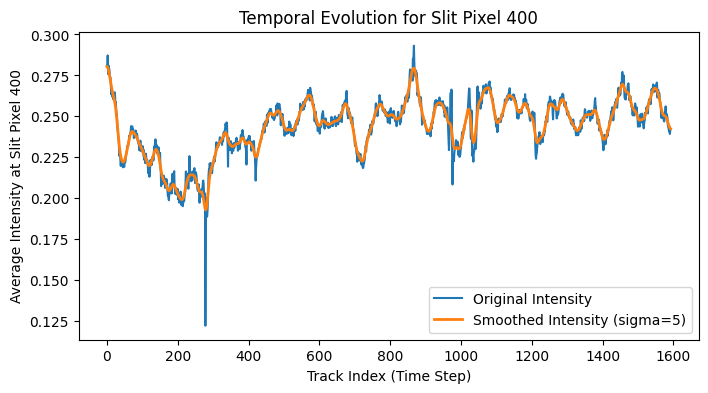

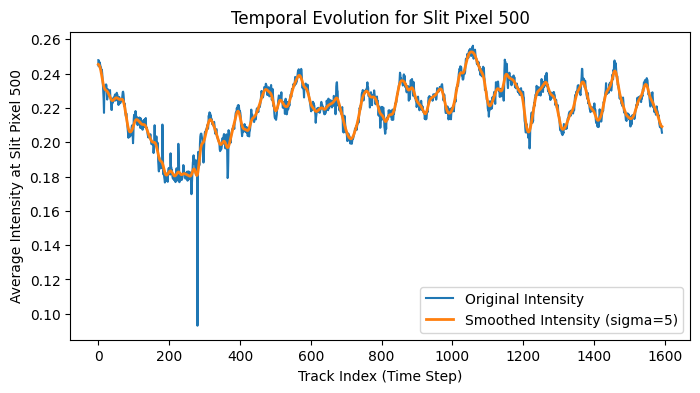

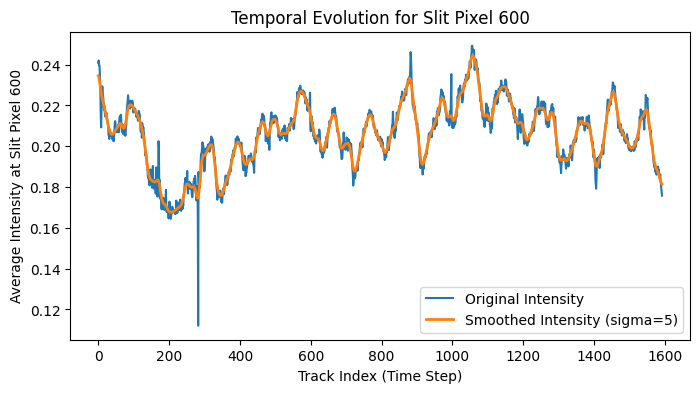

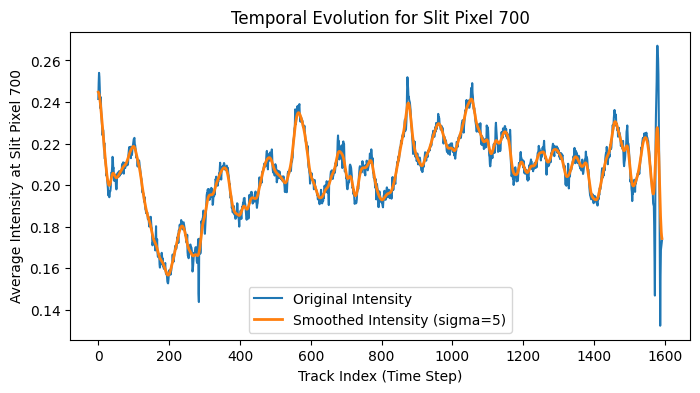

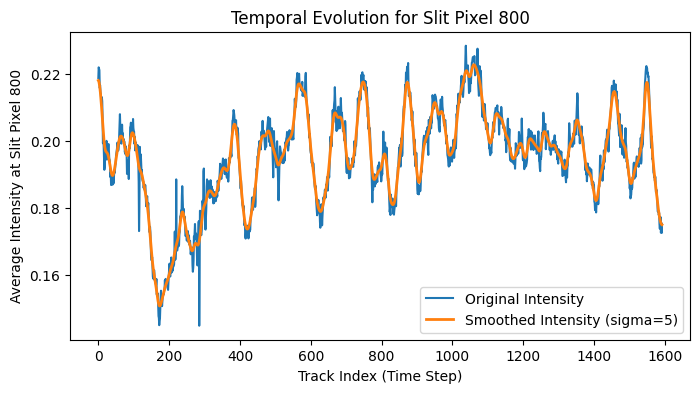

In [10]:
for i in range(1, 9):
    ilf.plot_pixel_temporal_evolution(data, pixel_index=100 * i, sigma=5)

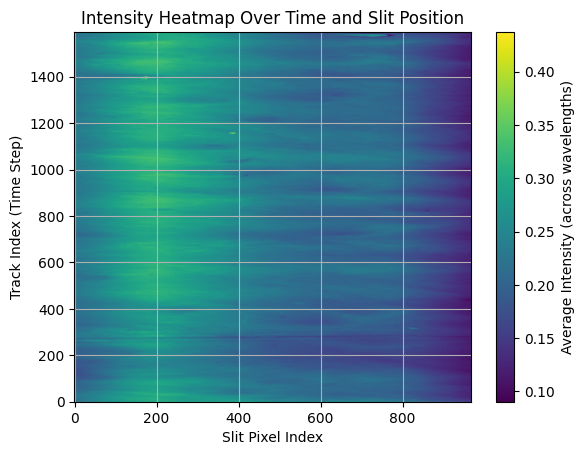

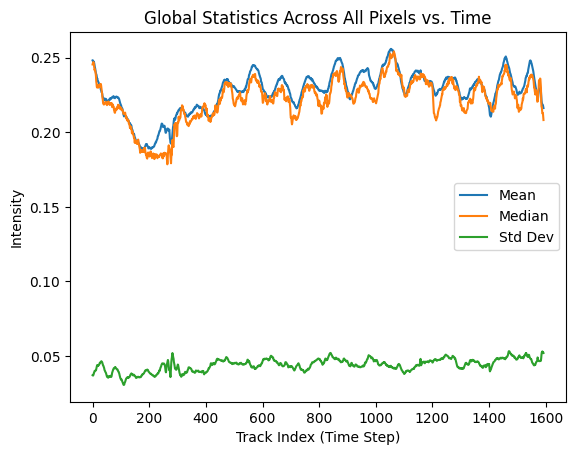

In [11]:
ilf.plot_intensity_heatmap(data)
ilf.plot_global_stats_over_time(data)

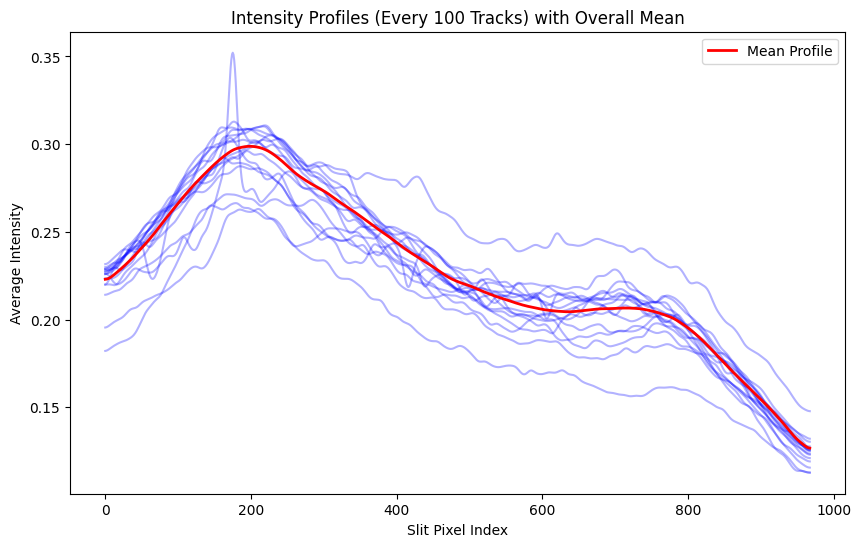

In [12]:
ilf.plot_all_profiles(data, 100, sigma=5)

### CORRECTION WITH POLYNOMIAL ###

In [13]:
track_index = 110
excluded_regions = [(150, 250), (700, 850)]  # the dip regions
# excluded_regions = [(100, 300), (700, 800)]  # the dip regions
poly_degree = 5
alpha = 1  # adjust to <1 if you want a partial correction
output_path = r"C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\29\uhi_rad\test\test_4_rad_uhi_20241029_104221_1.h5"

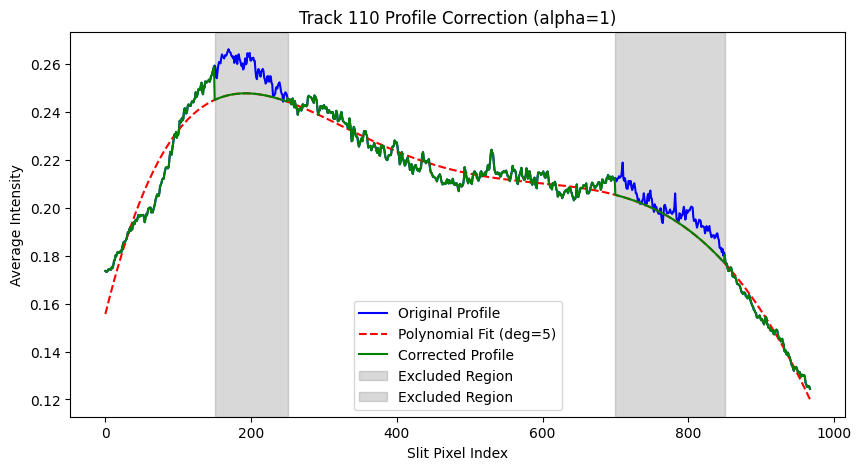

In [14]:
# Plot the correction for the chosen track
ilf.plot_corrected_profile_adjustment(
    data, track_index, poly_degree, excluded_regions, alpha
)

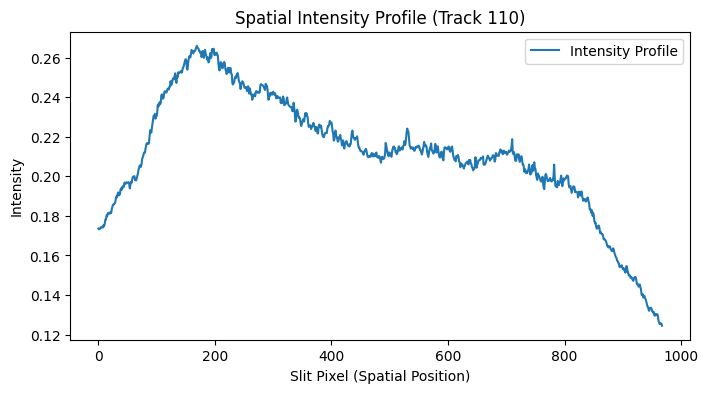

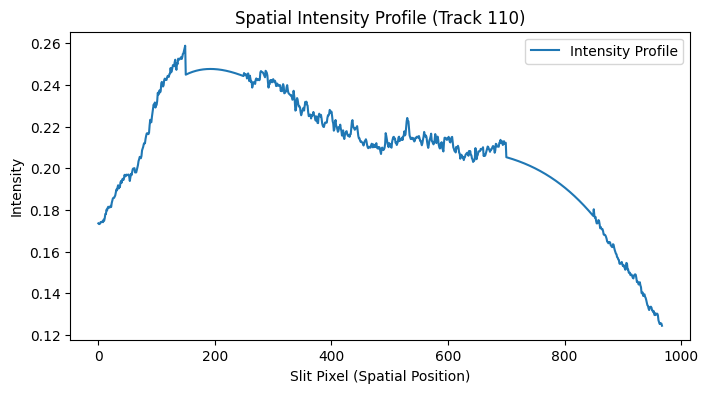

In [15]:
corrected_data = ilf.get_corrected_profile(data, poly_degree, excluded_regions, alpha)


ilf.plot_spatial_spectre(data, track_index=track_index)
ilf.plot_spatial_spectre(corrected_data, track_index=track_index)

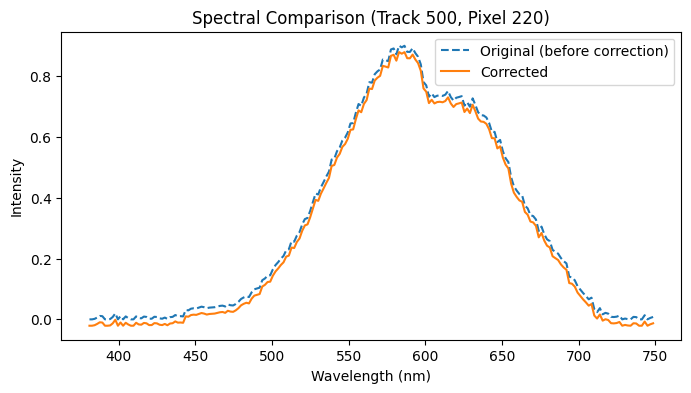

In [16]:
ilf.compare_spectral_profiles(
    data,
    corrected_data,
    track_index=500,
    spatial_index=220,
    wavelengths=band_2_wavelength,
)

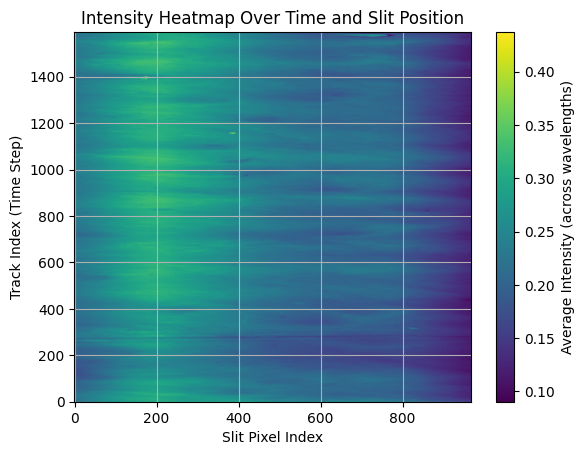

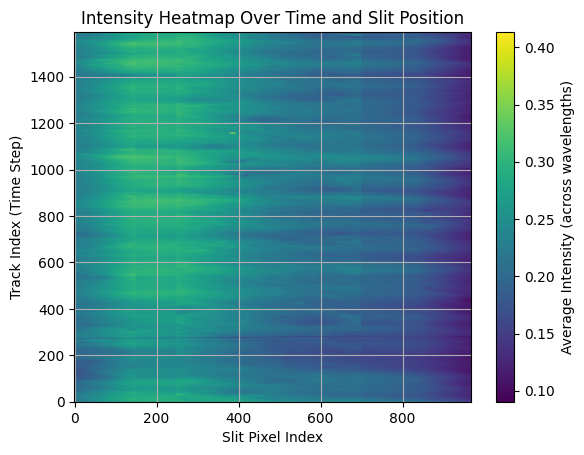

In [17]:
ilf.plot_intensity_heatmap(data)
ilf.plot_intensity_heatmap(corrected_data)

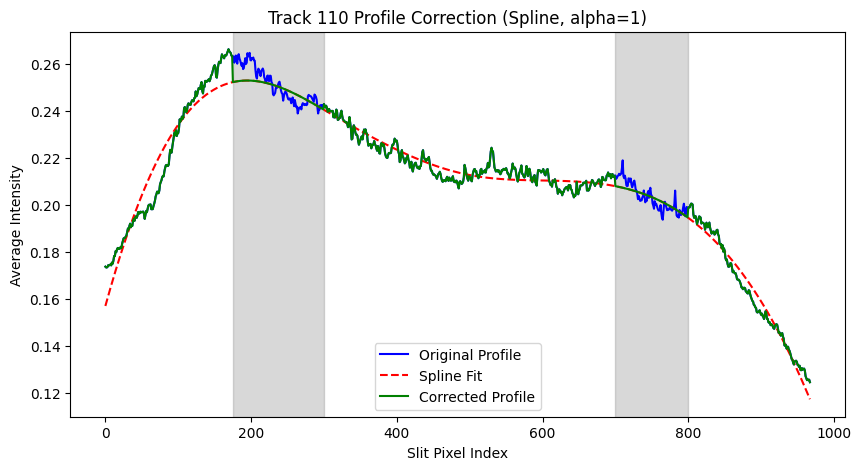

In [22]:
track_index = 110
excluded_regions = [(175, 300), (700, 800)]  # same idea as polynomial
smoothing_factor = 0.02
# tweak to your data
alpha = 1

# 1) Plot the spline-based correction for one track
ilf.plot_corrected_profile_adjustment_spline(
    data,
    track_index=track_index,
    exclude_ranges=excluded_regions,
    smoothing_factor=smoothing_factor,
    alpha=alpha,
)

# 2) Generate a fully corrected data cube (all tracks)
# corrected_data_spline = ilf.get_corrected_profile_spline(
#     data,
#     exclude_ranges=excluded_regions,
#     smoothing_factor=smoothing_factor,
#     alpha=alpha,
# )

# # 3) Compare original vs. corrected on some track or pixel
# ilf.plot_spatial_spectre(data, track_index=track_index)
# ilf.plot_spatial_spectre(corrected_data_spline, track_index=track_index)

In [19]:
ilf.correct_illumination_all_tracks(
    data=data,
    original_path=filename,
    output_path=output_path,
    poly_degree=poly_degree,
    exclude_ranges=excluded_regions,
)

Corrected data cube saved to: C:\Users\Erik Liu\OneDrive - NTNU\PhD\Courses\UHI post processing\29\uhi_rad\test\test_4_rad_uhi_20241029_104221_1.h5


array([[[0.01941589, 0.01924302, 0.        , ..., 0.00050929,
         0.        , 0.01073564],
        [0.01720214, 0.01601165, 0.        , ..., 0.01715108,
         0.        , 0.01908477],
        [0.0174931 , 0.01026364, 0.        , ..., 0.01872183,
         0.        , 0.01776016],
        ...,
        [0.01008252, 0.00147416, 0.        , ..., 0.01839956,
         0.        , 0.00909015],
        [0.00629307, 0.00308235, 0.        , ..., 0.0136106 ,
         0.        , 0.01062456],
        [0.00537201, 0.00711759, 0.00202693, ..., 0.00830519,
         0.        , 0.02089317]],

       [[0.        , 0.        , 0.00066185, ..., 0.        ,
         0.        , 0.00339447],
        [0.        , 0.        , 0.        , ..., 0.01290173,
         0.        , 0.00274426],
        [0.        , 0.00784138, 0.00573401, ..., 0.00131152,
         0.        , 0.01299573],
        ...,
        [0.00044416, 0.00252115, 0.0023342 , ..., 0.        ,
         0.        , 0.        ],
        [0. 